# 01 - Data Understanding

            Mục tiêu notebook này:

            - Hiểu bộ dữ liệu gốc.
            - Kiểm tra shape, column, dtype.
            - Kiểm tra missing value.
            - Kiểm tra phân phối target `fraud`.
            - Đọc các report giai đoạn 1 nếu đã sinh từ script.

In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: e:\fraud-detection-project


In [2]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "data" / "reports"

print("Raw files:")
for p in RAW_DIR.glob("*"):
    print("-", p.name)

Raw files:
- fraud2.csv
- fraud_metadata (2).xlsx


In [3]:
# Ưu tiên tên file chuẩn. Nếu bạn đang dùng tên khác, sửa lại biến DATA_PATH.
DATA_PATH = RAW_DIR / "fraud2.csv"
METADATA_PATH = RAW_DIR / "fraud_metadata.xlsx"

if not DATA_PATH.exists():
    csv_candidates = list(RAW_DIR.glob("*.csv"))
    if not csv_candidates:
        raise FileNotFoundError("Không tìm thấy file CSV trong data/raw")
    DATA_PATH = csv_candidates[0]

print("Using DATA_PATH:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head()

Using DATA_PATH: e:\fraud-detection-project\data\raw\fraud2.csv


,amount,currency,local_timestamp,payment_channel,merchant_country,mcc,card_present,ip_risk,device_id,card_entry_mode,auth_result,merchant_id,pin_verif_method,tokenised,recurring_flag,cross_border,card_activation_age,auth_characteristics,message_type,mean_amount_30d,std_amount_30d,max_amount_30d,txn_counts,distinct_merchants_7d,distinct_countries_30d,online_share_7d,night_ratio_30d,days_since_last_txn,decline_rate_30d,chargebacks_365d,device_diversity_30d,mcc_entropy_30d,credit_util_today,spending_trend,term_location,fraud
0,100606.12,USD,2025-03-19 10:23:03,ATM,PH,7736,True,"{'ip': '190.3.86.171', 'score': 0.1467}",DEV-7726FB1A8A274C4B,CHIP,3DS_FAIL,MID-2585C551D674,OFFLINE_PIN,False,MOTO_PHONE,True,4282,FALLBACK_MAG,0110-AuthRsp,5.19,6.62,34046.16,"(13, 21)",112,2,0.210,0.084,100,0.271,3,27,0.801,0.943,1.460,BRANCH_COUNTER,0
1,146953.67,USD,2025-05-16 00:35:42,WEB_BROWSER,GB,3242,False,"{'ip': '79.201.116.230', 'score': 0.5243}",DEV-68CD2988A8C345AC,CHIP,BIOMETRIC_PASS,MID-CA3988467DD9,ONLINE_PIN,True,INSTALLMENT_PLAN,False,3804,CRYPTOGRAM_PRESENT,0110-AuthRsp,6.18,35.50,7146.37,"(22, 256)",3,9,0.665,0.751,177,0.098,3,17,0.651,1.269,4.980,BRANCH_COUNTER,0
2,161096.38,USD,2025-04-10 03:03:24,ATM,US,5638,True,"{'ip': '16.247.34.115', 'score': 0.4811}",DEV-C75EBE4E1BCB4362,TOKEN_IN_APP,CVV_FAIL,MID-9D430F327DF7,OFFLINE_PIN,True,RECURRING_SUBSCRIPTION,False,2292,E_COMMERCE,0110-AuthRsp,5.80,4.32,72447.86,"(13, 29)",40,16,0.322,0.637,34,0.092,0,11,0.646,0.291,4.514,KIOSK,0
3,131491.00,CNY,2025-03-28 02:39:22,MOBILE_APP,JP,7800,False,"{'ip': '23.130.177.181', 'score': 0.3218}",DEV-DFE8A6350785435B,MAGSTRIPE,3DS_PASS,MID-6E0F7E9155DB,OFFLINE_PIN,False,MOTO_PHONE,False,2711,E_COMMERCE,0420-RepeatRev,5.29,3.84,228799.51,"(58, 375)",21,3,0.233,0.497,132,0.055,0,23,1.638,1.202,1.316,CALL_CENTER,0
4,71265.99,CNY,2025-05-18 12:14:09,SMART_WATCH,PH,5789,False,"{'ip': '9.44.12.213', 'score': 0.1168}",DEV-07B9EB6E54CC459C,CHIP,CVV_FAIL,MID-0C99A14622F8,ONLINE_PIN,False,MOTO_MAIL,False,2845,CARD_PRESENT,0110-AuthRsp,6.69,1.82,108426.28,"(60, 266)",100,6,0.909,0.831,162,0.201,0,16,2.033,1.846,3.805,POS_TERMINAL,0


In [4]:
print("Shape:", df.shape)
display(df.head())
display(df.tail())

Shape: (100000, 36)


,amount,currency,local_timestamp,payment_channel,merchant_country,mcc,card_present,ip_risk,device_id,card_entry_mode,auth_result,merchant_id,pin_verif_method,tokenised,recurring_flag,cross_border,card_activation_age,auth_characteristics,message_type,mean_amount_30d,std_amount_30d,max_amount_30d,txn_counts,distinct_merchants_7d,distinct_countries_30d,online_share_7d,night_ratio_30d,days_since_last_txn,decline_rate_30d,chargebacks_365d,device_diversity_30d,mcc_entropy_30d,credit_util_today,spending_trend,term_location,fraud
0,100606.12,USD,2025-03-19 10:23:03,ATM,PH,7736,True,"{'ip': '190.3.86.171', 'score': 0.1467}",DEV-7726FB1A8A274C4B,CHIP,3DS_FAIL,MID-2585C551D674,OFFLINE_PIN,False,MOTO_PHONE,True,4282,FALLBACK_MAG,0110-AuthRsp,5.19,6.62,34046.16,"(13, 21)",112,2,0.210,0.084,100,0.271,3,27,0.801,0.943,1.460,BRANCH_COUNTER,0
1,146953.67,USD,2025-05-16 00:35:42,WEB_BROWSER,GB,3242,False,"{'ip': '79.201.116.230', 'score': 0.5243}",DEV-68CD2988A8C345AC,CHIP,BIOMETRIC_PASS,MID-CA3988467DD9,ONLINE_PIN,True,INSTALLMENT_PLAN,False,3804,CRYPTOGRAM_PRESENT,0110-AuthRsp,6.18,35.50,7146.37,"(22, 256)",3,9,0.665,0.751,177,0.098,3,17,0.651,1.269,4.980,BRANCH_COUNTER,0
2,161096.38,USD,2025-04-10 03:03:24,ATM,US,5638,True,"{'ip': '16.247.34.115', 'score': 0.4811}",DEV-C75EBE4E1BCB4362,TOKEN_IN_APP,CVV_FAIL,MID-9D430F327DF7,OFFLINE_PIN,True,RECURRING_SUBSCRIPTION,False,2292,E_COMMERCE,0110-AuthRsp,5.80,4.32,72447.86,"(13, 29)",40,16,0.322,0.637,34,0.092,0,11,0.646,0.291,4.514,KIOSK,0
3,131491.00,CNY,2025-03-28 02:39:22,MOBILE_APP,JP,7800,False,"{'ip': '23.130.177.181', 'score': 0.3218}",DEV-DFE8A6350785435B,MAGSTRIPE,3DS_PASS,MID-6E0F7E9155DB,OFFLINE_PIN,False,MOTO_PHONE,False,2711,E_COMMERCE,0420-RepeatRev,5.29,3.84,228799.51,"(58, 375)",21,3,0.233,0.497,132,0.055,0,23,1.638,1.202,1.316,CALL_CENTER,0
4,71265.99,CNY,2025-05-18 12:14:09,SMART_WATCH,PH,5789,False,"{'ip': '9.44.12.213', 'score': 0.1168}",DEV-07B9EB6E54CC459C,CHIP,CVV_FAIL,MID-0C99A14622F8,ONLINE_PIN,False,MOTO_MAIL,False,2845,CARD_PRESENT,0110-AuthRsp,6.69,1.82,108426.28,"(60, 266)",100,6,0.909,0.831,162,0.201,0,16,2.033,1.846,3.805,POS_TERMINAL,0


,amount,currency,local_timestamp,payment_channel,merchant_country,mcc,card_present,ip_risk,device_id,card_entry_mode,auth_result,merchant_id,pin_verif_method,tokenised,recurring_flag,cross_border,card_activation_age,auth_characteristics,message_type,mean_amount_30d,std_amount_30d,max_amount_30d,txn_counts,distinct_merchants_7d,distinct_countries_30d,online_share_7d,night_ratio_30d,days_since_last_txn,decline_rate_30d,chargebacks_365d,device_diversity_30d,mcc_entropy_30d,credit_util_today,spending_trend,term_location,fraud
99995,55686.40,USD,2025-04-06 12:08:40,MOBILE_APP,KR,5208,True,"{'ip': '49.143.25.111', 'score': 0.518}",DEV-7464BF966FCD4F46,QR_CODE,BIOMETRIC_FAIL,MID-B67DB7C5974C,SIGNATURE,True,INSTALLMENT_PLAN,False,2740,CARD_PRESENT,0210-FinRsp,7.01,3.89,113100.50,"(0, 1)",11,2,0.306,0.424,126,0.211,0,8,2.366,0.108,0.886,BRANCH_COUNTER,0
99996,73642.38,GBP,2025-05-26 12:22:03,SMART_WATCH,AE,3292,False,"{'ip': '184.71.56.209', 'score': 0.1245}",DEV-7E0F1FC7EE484E6D,QR_CODE,3DS_FAIL,MID-BA9A95BB0BE3,NONE,True,SINGLE_PURCHASE,False,3508,FORCE_POST,0110-AuthRsp,6.84,1.61,243100.65,"(98, 175)",59,19,0.952,0.296,125,0.049,0,25,1.909,1.462,4.433,MOBILE_APP,0
99997,88505.04,INR,2025-05-25 18:09:46,SMART_WATCH,ZA,4826,True,"{'ip': '253.168.22.184', 'score': 0.2592}",DEV-A329842924FF43E2,CHIP,AVS_FAIL,MID-E53D9D822F21,SIGNATURE,True,INSTALLMENT_PLAN,True,4288,CARD_PRESENT,0500-Advice,6.28,1.33,115992.69,"(16, 275)",98,5,0.509,0.974,125,0.030,0,35,2.834,1.865,3.277,KIOSK,0
99998,66605.70,AUD,2025-03-20 08:23:34,IVR_PHONE,FR,7241,False,"{'ip': '95.183.242.238', 'score': 0.7109}",DEV-9BB30F27847744AF,TOKEN_IN_APP,CVV_PASS,MID-98CA906C3E81,ONLINE_PIN,False,SINGLE_PURCHASE,True,2674,E_COMMERCE,0100-AuthReq,15.33,13.77,213605.27,"(70, 391)",34,25,0.205,0.937,95,0.154,1,12,2.547,0.501,2.124,POS_TERMINAL,0
99999,68527.19,INR,2025-03-20 18:01:29,WEB_BROWSER,JP,3328,False,"{'ip': '3.27.219.206', 'score': 0.3737}",DEV-E0A74B5F713148AA,QR_CODE,AVS_FAIL,MID-7666BF399151,SIGNATURE,True,INSTALLMENT_PLAN,False,3978,E_COMMERCE,0400-Reversal,7.20,2.90,14377.59,"(10, 247)",117,15,0.670,0.438,88,0.154,0,26,2.818,1.036,0.848,ONLINE_PORTAL,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   amount                  100000 non-null  float64
 1   currency                100000 non-null  str    
 2   local_timestamp         100000 non-null  str    
 3   payment_channel         100000 non-null  str    
 4   merchant_country        100000 non-null  str    
 5   mcc                     100000 non-null  int64  
 6   card_present            100000 non-null  bool   
 7   ip_risk                 100000 non-null  str    
 8   device_id               100000 non-null  str    
 9   card_entry_mode         100000 non-null  str    
 10  auth_result             100000 non-null  str    
 11  merchant_id             100000 non-null  str    
 12  pin_verif_method        100000 non-null  str    
 13  tokenised               100000 non-null  bool   
 14  recurring_flag          100000 n

In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
amount,100000.0,NaN,NaN,NaN,100258.956341,57846.453927,1.43,50047.35,100477.09,150467.41,199999.75
currency,100000,15,USD,38201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
local_timestamp,100000,99371,2025-04-16 11:34:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_channel,100000,7,WEB_BROWSER,14469,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_country,100000,20,BR,5145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mcc,100000.0,NaN,NaN,NaN,5174.55836,1599.107713,3000.0,4004.0,5003.0,7003.0,7999.0
card_present,100000,2,False,65166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_risk,100000,100000,"{'ip': '190.3.86.171', 'score': 0.1467}",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_id,100000,100000,DEV-7726FB1A8A274C4B,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card_entry_mode,100000,6,CHIP,16857,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,fraud,count,ratio
0,0,97451,0.97451
1,1,2549,0.02549


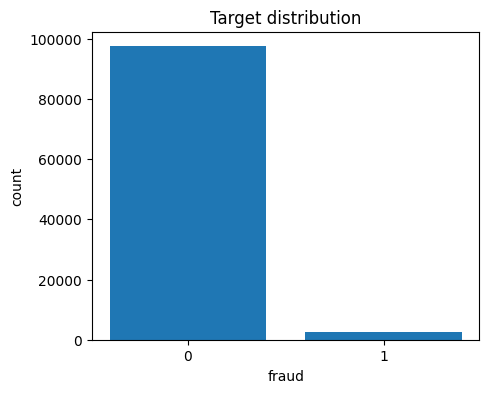

In [7]:
TARGET_COL = "fraud"

if TARGET_COL in df.columns:
    target_dist = (
        df[TARGET_COL]
        .value_counts(dropna=False)
        .rename_axis(TARGET_COL)
        .reset_index(name="count")
    )
    target_dist["ratio"] = target_dist["count"] / len(df)
    display(target_dist)

    plt.figure(figsize=(5, 4))
    plt.bar(target_dist[TARGET_COL].astype(str), target_dist["count"])
    plt.title("Target distribution")
    plt.xlabel(TARGET_COL)
    plt.ylabel("count")
    plt.show()
else:
    print(f"Không tìm thấy target column: {TARGET_COL}")

In [8]:
missing = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing.columns = ["column", "missing_rate"]
display(missing.head(40))

,column,missing_rate
0,amount,0.0
1,currency,0.0
2,local_timestamp,0.0
3,payment_channel,0.0
4,merchant_country,0.0
5,mcc,0.0
6,card_present,0.0
7,ip_risk,0.0
8,device_id,0.0
9,card_entry_mode,0.0


In [9]:
dtype_report = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    "missing_rate": [df[c].isna().mean() for c in df.columns],
})
display(dtype_report.sort_values(["missing_rate", "n_unique"], ascending=[False, False]).head(50))

,column,dtype,n_unique,missing_rate
7,ip_risk,str,100000,0.0
8,device_id,str,100000,0.0
11,merchant_id,str,100000,0.0
21,max_amount_30d,float64,99827,0.0
0,amount,float64,99765,0.0
2,local_timestamp,str,99371,0.0
22,txn_counts,str,39665,0.0
33,spending_trend,float64,4901,0.0
16,card_activation_age,int64,4381,0.0
31,mcc_entropy_30d,float64,4001,0.0


In [10]:
# Đọc các report giai đoạn 1 nếu tồn tại
candidate_reports = [
    "dataset_overview.csv",
    "column_overview.csv",
    "column_types.csv",
    "missing_report.csv",
    "target_distribution.csv",
    "high_cardinality_report.csv",
]

for file in candidate_reports:
    path = REPORT_DIR / file
    if path.exists():
        print("\n" + "=" * 100)
        print(file)
        display(pd.read_csv(path).head(30))


dataset_overview.csv


,num_rows,num_columns,duplicate_rows,duplicate_rate,total_missing_values,total_missing_rate,target_column,fraud_count,non_fraud_count,fraud_rate
0,100000,36,0,0.0,0,0.0,fraud,2549,97451,0.02549



column_overview.csv


,column,dtype,non_null_count,null_count,null_rate,unique_count,unique_rate,sample_values
0,device_id,str,100000,0,0.0,100000,1.00000,"DEV-7726FB1A8A274C4B, DEV-68CD2988A8C345AC, DE..."
1,merchant_id,str,100000,0,0.0,100000,1.00000,"MID-2585C551D674, MID-CA3988467DD9, MID-9D430F..."
2,ip_risk,str,100000,0,0.0,100000,1.00000,"{'ip': '190.3.86.171', 'score': 0.1467}, {'ip'..."
3,max_amount_30d,float64,100000,0,0.0,99827,0.99827,"34046.16, 7146.37, 72447.86, 228799.51, 108426.28"
4,amount,float64,100000,0,0.0,99765,0.99765,"100606.12, 146953.67, 161096.38, 131491.0, 712..."
5,local_timestamp,str,100000,0,0.0,99371,0.99371,"2025-03-19 10:23:03, 2025-05-16 00:35:42, 2025..."
6,txn_counts,str,100000,0,0.0,39665,0.39665,"(13, 21), (22, 256), (13, 29), (58, 375), (60,..."
7,spending_trend,float64,100000,0,0.0,4901,0.04901,"1.46, 4.98, 4.514, 1.316, 3.805"
8,card_activation_age,int64,100000,0,0.0,4381,0.04381,"4282, 3804, 2292, 2711, 2845"
9,mcc_entropy_30d,float64,100000,0,0.0,4001,0.04001,"0.801, 0.651, 0.646, 1.638, 2.033"



column_types.csv


...

,column,missing_count,missing_rate,non_missing_count
0,amount,0,0.0,100000
1,currency,0,0.0,100000
2,local_timestamp,0,0.0,100000
3,payment_channel,0,0.0,100000
4,merchant_country,0,0.0,100000
5,mcc,0,0.0,100000
6,card_present,0,0.0,100000
7,ip_risk,0,0.0,100000
8,device_id,0,0.0,100000
9,card_entry_mode,0,0.0,100000



target_distribution.csv


,fraud,count,rate
0,0,97451,0.97451
1,1,2549,0.02549



high_cardinality_report.csv


,column,dtype,unique_count,unique_rate,note
0,amount,float64,99765,0.99765,High cardinality - không nên one-hot trực tiếp
1,local_timestamp,str,99371,0.99371,High cardinality - không nên one-hot trực tiếp
2,mcc,int64,3351,0.03351,High cardinality - không nên one-hot trực tiếp
3,ip_risk,str,100000,1.00000,High cardinality - không nên one-hot trực tiếp
4,device_id,str,100000,1.00000,High cardinality - không nên one-hot trực tiếp
5,merchant_id,str,100000,1.00000,High cardinality - không nên one-hot trực tiếp
6,card_activation_age,int64,4381,0.04381,High cardinality - không nên one-hot trực tiếp
7,mean_amount_30d,float64,2252,0.02252,High cardinality - không nên one-hot trực tiếp
8,std_amount_30d,float64,1494,0.01494,High cardinality - không nên one-hot trực tiếp
9,max_amount_30d,float64,99827,0.99827,High cardinality - không nên one-hot trực tiếp


## Kết luận cần ghi sau khi chạy

            - Dataset có bao nhiêu dòng/cột?
            - Target fraud bị mất cân bằng bao nhiêu?
            - Nhóm cột nào nhiều missing?
            - Có cột categorical cardinality cao nào cần xử lý không?